# 🎫 Task 2 – Support Ticket Classification
**Future Interns | Machine Learning Track**

**Objective:** Build a system to automatically classify customer support tickets and assign priority levels.

**Skills Gained:** Text preprocessing, NLP classification, priority logic, support analytics

**Dataset:** `customer_support_tickets.csv` – Real customer support ticket data with descriptions, types, priorities, and statuses.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, os, string
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

os.makedirs('output', exist_ok=True)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print('✅ Libraries imported')

✅ Libraries imported


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('dataset/customer_support_tickets.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(5)

Shape: (8469, 17)
Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
print('Missing values:')
print(df.isnull().sum())
print('\nTicket Type distribution:')
print(df['Ticket Type'].value_counts())
print('\nTicket Priority distribution:')
print(df['Ticket Priority'].value_counts())
print('\nTicket Status distribution:')
print(df['Ticket Status'].value_counts())

Missing values:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Ticket Type distribution:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Ticket Priority distribution:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtyp

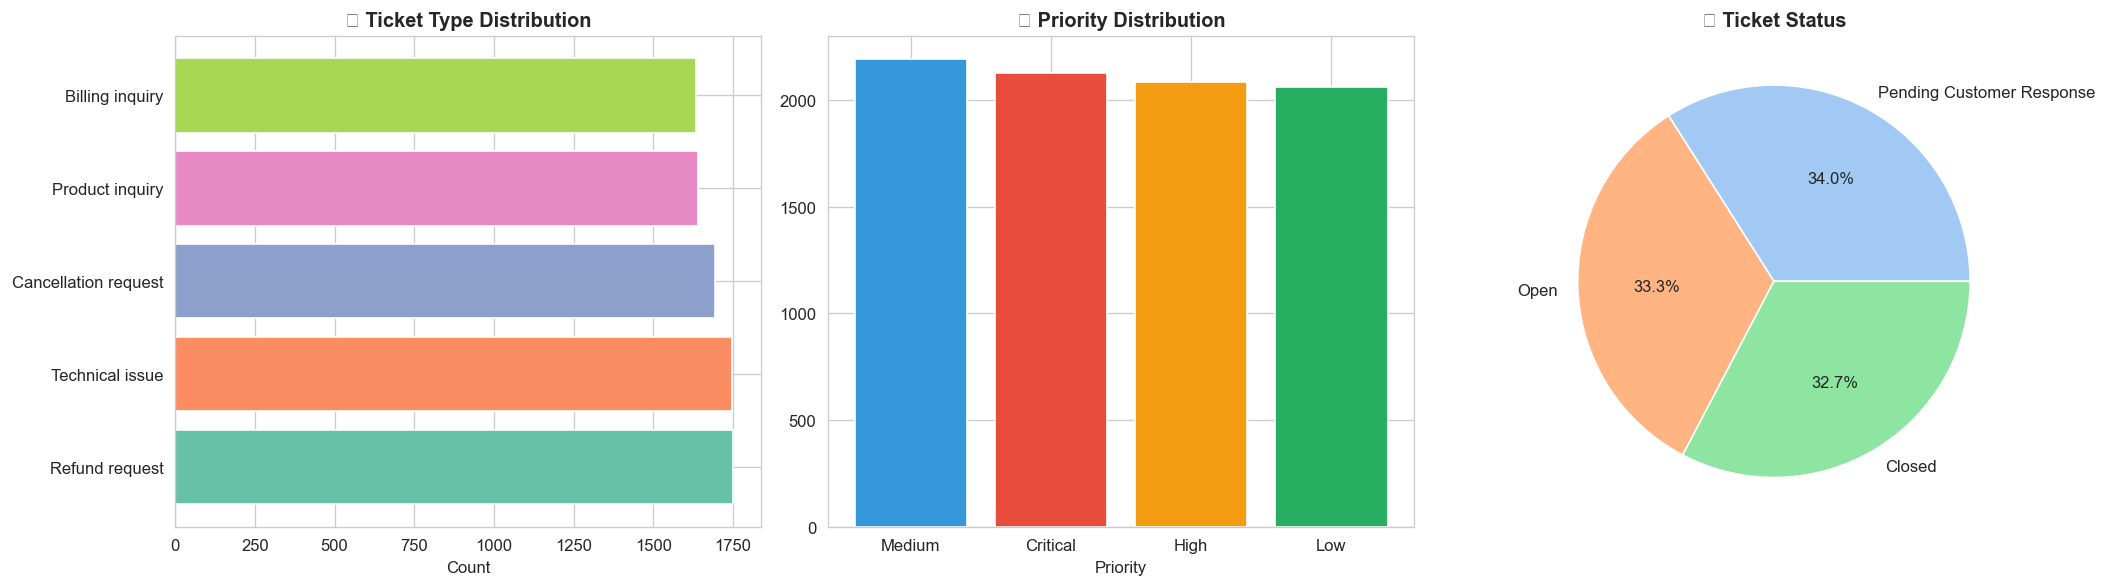

✅ Saved: output/01_eda_distributions.png


In [4]:
# EDA – Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ticket Type
type_counts = df['Ticket Type'].value_counts()
axes[0].barh(type_counts.index, type_counts.values,
             color=sns.color_palette('Set2', len(type_counts)))
axes[0].set_title('🎫 Ticket Type Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')

# Priority
priority_counts = df['Ticket Priority'].value_counts()
colors_p = {'Critical':'#e74c3c','High':'#f39c12','Medium':'#3498db','Low':'#27ae60'}
bar_colors = [colors_p.get(p, 'gray') for p in priority_counts.index]
axes[1].bar(priority_counts.index, priority_counts.values, color=bar_colors)
axes[1].set_title('⚡ Priority Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Priority')

# Status
status_counts = df['Ticket Status'].value_counts()
axes[2].pie(status_counts.values, labels=status_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[2].set_title('📊 Ticket Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('output/01_eda_distributions.png', bbox_inches='tight')
plt.show()
print('✅ Saved: output/01_eda_distributions.png')

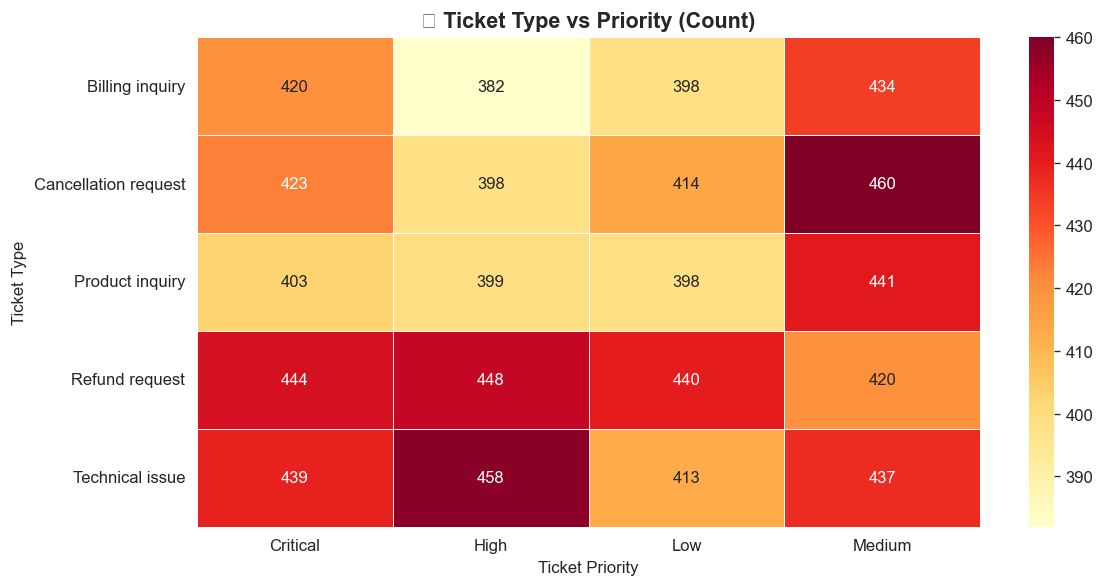

✅ Saved: output/02_type_priority_heatmap.png


In [5]:
# Priority vs Ticket Type heatmap
cross = pd.crosstab(df['Ticket Type'], df['Ticket Priority'])
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('🔥 Ticket Type vs Priority (Count)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/02_type_priority_heatmap.png', bbox_inches='tight')
plt.show()
print('✅ Saved: output/02_type_priority_heatmap.png')

## 3. Text Cleaning & Tokenization

In [6]:
STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Full NLP text cleaning pipeline."""
    if pd.isnull(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'\{[^}]+\}', '', text)          # Remove template placeholders
    text = re.sub(r'http\S+|www\S+', '', text)       # Remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)            # Remove punctuation/digits
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOPWORDS and len(t) > 2]
    return ' '.join(tokens)

print('Cleaning text...')
df['clean_description'] = df['Ticket Description'].apply(clean_text)
df['clean_subject']     = df['Ticket Subject'].apply(clean_text)
df['combined_text']     = df['clean_subject'] + ' ' + df['clean_description']

# Show before/after
print('\nBefore:', df['Ticket Description'].iloc[0][:120])
print('\nAfter :', df['clean_description'].iloc[0][:120])

Cleaning text...

Before: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that y

After : issue please assist billing zip code appreciate requested website address please double check email address tried troubl


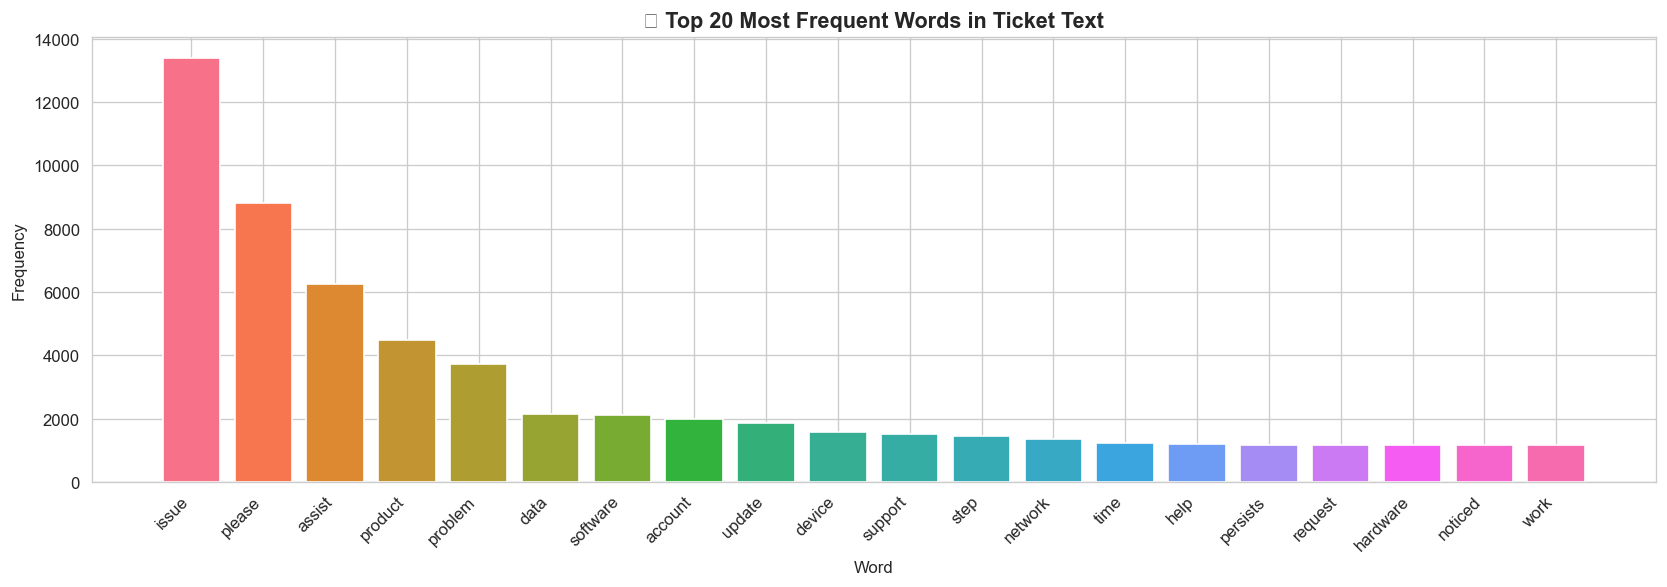

✅ Saved: output/03_word_frequency.png


In [7]:
# Word frequency analysis
from collections import Counter
all_words = ' '.join(df['combined_text']).split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(words, freqs, color=sns.color_palette('husl', 20))
ax.set_title('📝 Top 20 Most Frequent Words in Ticket Text', fontsize=13, fontweight='bold')
ax.set_xlabel('Word'); ax.set_ylabel('Frequency')
ax.set_xticklabels(words, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output/03_word_frequency.png', bbox_inches='tight')
plt.show()
print('✅ Saved: output/03_word_frequency.png')

## 4. Ticket Category Classification (Ticket Type)

In [8]:
# Drop rows with missing labels
df_cat = df[df['Ticket Type'].notna() & (df['combined_text'].str.len() > 5)].copy()

le_type = LabelEncoder()
y_type = le_type.fit_transform(df_cat['Ticket Type'])
X_text = df_cat['combined_text']

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_type, test_size=0.2, random_state=42, stratify=y_type
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Classes: {le_type.classes_}')

Train: 6775 | Test: 1694
Classes: ['Billing inquiry' 'Cancellation request' 'Product inquiry'
 'Refund request' 'Technical issue']


In [9]:
# Build and train 3 classification pipelines
classifiers = {
    'Naive Bayes':       Pipeline([('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
                                    ('clf',  MultinomialNB())]),
    'Logistic Regression': Pipeline([('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
                                       ('clf',  LogisticRegression(max_iter=500, random_state=42))]),
    'Random Forest':     Pipeline([('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
                                    ('clf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])
}

cat_results = {}
cat_predictions = {}

for name, pipe in classifiers.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    cat_predictions[name] = preds
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    cat_results[name] = {'Accuracy': acc, 'F1 (weighted)': f1}
    print(f'{name:25s} → Accuracy: {acc:.4f} | F1: {f1:.4f}')

best_cat_name = max(cat_results, key=lambda k: cat_results[k]['F1 (weighted)'])
print(f'\n🏆 Best Classifier: {best_cat_name}')

Naive Bayes               → Accuracy: 0.2054 | F1: 0.2039
Logistic Regression       → Accuracy: 0.2102 | F1: 0.2100
Random Forest             → Accuracy: 0.1942 | F1: 0.1937

🏆 Best Classifier: Logistic Regression


In [10]:
# Detailed classification report
print(f'=== Classification Report – {best_cat_name} ===')
print(classification_report(y_test, cat_predictions[best_cat_name],
                             target_names=le_type.classes_))

=== Classification Report – Logistic Regression ===
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.20      0.20       327
Cancellation request       0.21      0.21      0.21       339
     Product inquiry       0.20      0.20      0.20       328
      Refund request       0.20      0.21      0.20       351
     Technical issue       0.24      0.25      0.24       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694



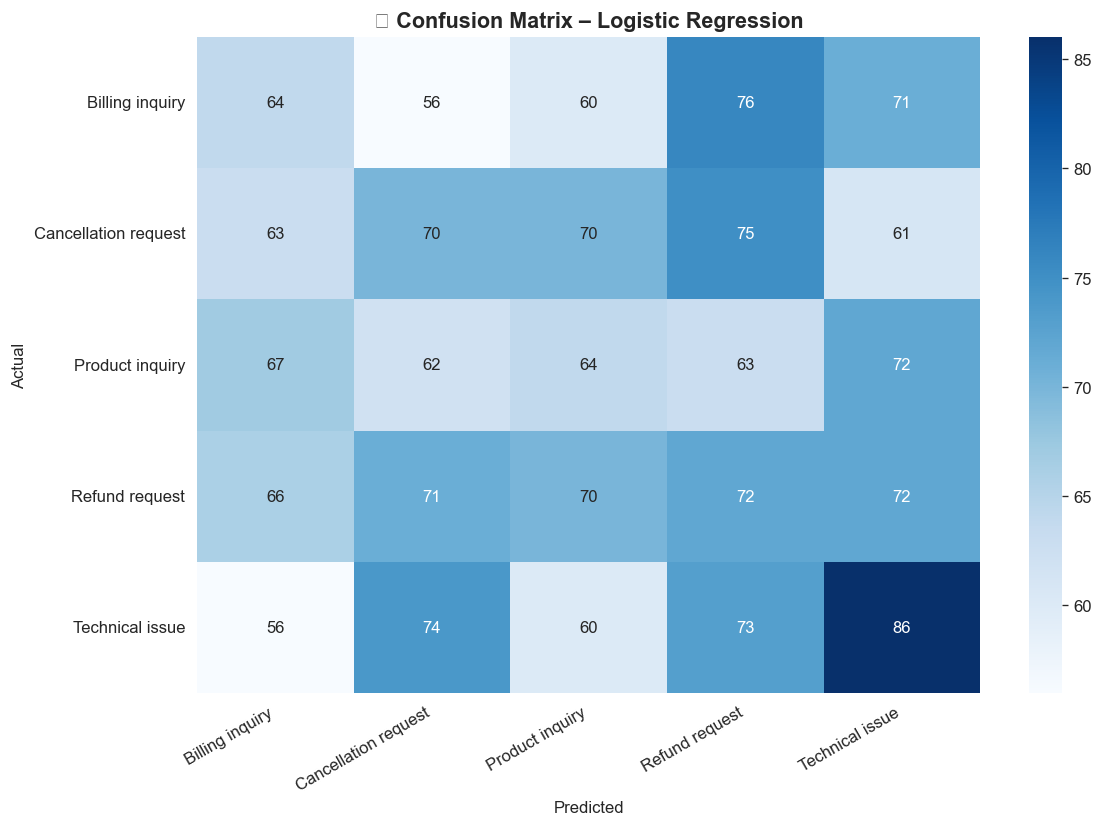

✅ Saved: output/04_confusion_matrix_type.png


In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, cat_predictions[best_cat_name])
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_type.classes_, yticklabels=le_type.classes_, ax=ax)
ax.set_title(f'🎯 Confusion Matrix – {best_cat_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('output/04_confusion_matrix_type.png', bbox_inches='tight')
plt.show()
print('✅ Saved: output/04_confusion_matrix_type.png')

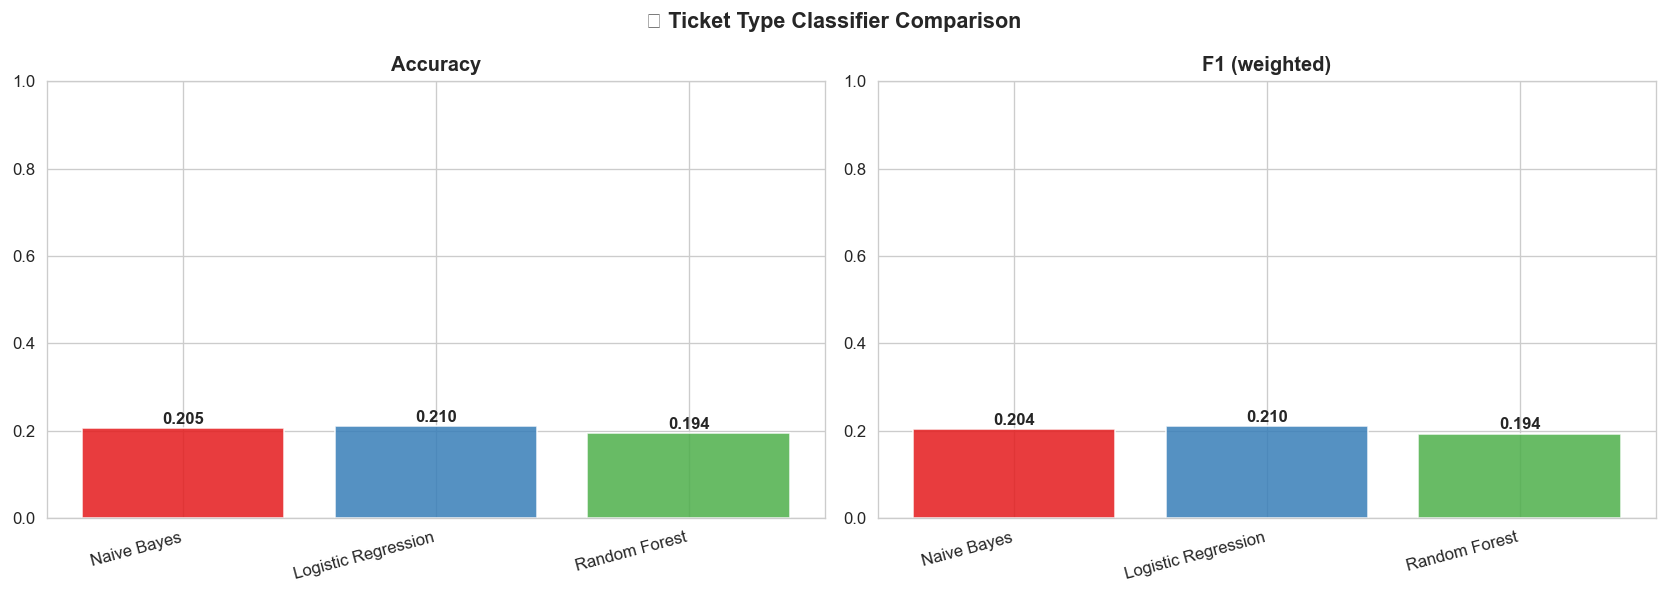

✅ Saved: output/05_classifier_comparison.png


In [12]:
# Model comparison bar chart
cat_df = pd.DataFrame(cat_results).T
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['Accuracy', 'F1 (weighted)']):
    vals = cat_df[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=sns.color_palette('Set1', len(vals)), alpha=0.85)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(vals.index, rotation=15, ha='right')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
fig.suptitle('📊 Ticket Type Classifier Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/05_classifier_comparison.png', bbox_inches='tight')
plt.show()
print('✅ Saved: output/05_classifier_comparison.png')

## 5. Priority Tagging (High / Medium / Low)

In [13]:
# Priority classification
df_pri = df[df['Ticket Priority'].notna() & (df['combined_text'].str.len() > 5)].copy()

le_priority = LabelEncoder()
y_priority = le_priority.fit_transform(df_pri['Ticket Priority'])
X_text_pri = df_pri['combined_text']

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_text_pri, y_priority, test_size=0.2, random_state=42, stratify=y_priority
)

print(f'Priority classes: {le_priority.classes_}')

# Best model for priority
pri_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf',   LogisticRegression(max_iter=500, C=1.0, random_state=42))
])
pri_pipe.fit(Xp_train, yp_train)
pri_preds = pri_pipe.predict(Xp_test)

print(f'Priority Accuracy: {accuracy_score(yp_test, pri_preds):.4f}')
print(f'Priority F1      : {f1_score(yp_test, pri_preds, average="weighted"):.4f}')
print()
print(classification_report(yp_test, pri_preds, target_names=le_priority.classes_))

Priority classes: ['Critical' 'High' 'Low' 'Medium']
Priority Accuracy: 0.2491
Priority F1      : 0.2491

              precision    recall  f1-score   support

    Critical       0.24      0.23      0.24       426
        High       0.28      0.26      0.27       417
         Low       0.23      0.23      0.23       413
      Medium       0.25      0.27      0.26       438

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694



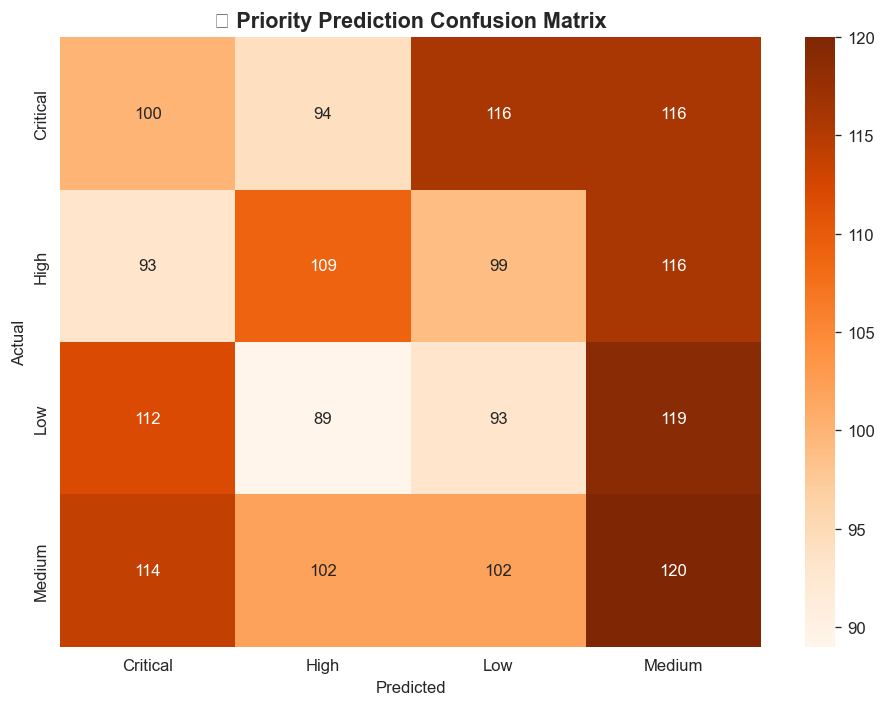

✅ Saved: output/06_confusion_matrix_priority.png


In [14]:
# Priority confusion matrix
cm_pri = confusion_matrix(yp_test, pri_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_pri, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_priority.classes_, yticklabels=le_priority.classes_, ax=ax)
ax.set_title('⚡ Priority Prediction Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('output/06_confusion_matrix_priority.png', bbox_inches='tight')
plt.show()
print('✅ Saved: output/06_confusion_matrix_priority.png')

## 6. Full Classification System – Demo

In [15]:
# Apply best models on full dataset to show end-to-end classification
best_cat_pipe = classifiers[best_cat_name]

df_full = df[df['combined_text'].str.len() > 5].copy()
df_full['predicted_type']     = le_type.inverse_transform(best_cat_pipe.predict(df_full['combined_text']))
df_full['predicted_priority'] = le_priority.inverse_transform(pri_pipe.predict(df_full['combined_text']))

output_cols = ['Ticket ID','Ticket Subject','Ticket Type','predicted_type',
               'Ticket Priority','predicted_priority']
result_df = df_full[output_cols].head(20)
print('Sample Classification Results:')
print(result_df.to_string(index=False))

Sample Classification Results:
 Ticket ID           Ticket Subject          Ticket Type       predicted_type Ticket Priority predicted_priority
         1            Product setup      Technical issue      Technical issue        Critical           Critical
         2 Peripheral compatibility      Technical issue      Technical issue        Critical             Medium
         3          Network problem      Technical issue      Technical issue             Low                Low
         4           Account access      Billing inquiry      Billing inquiry             Low                Low
         5                Data loss      Billing inquiry      Billing inquiry             Low                Low
         6            Payment issue Cancellation request       Refund request             Low           Critical
         7           Refund request      Product inquiry      Technical issue        Critical               High
         8             Battery life       Refund request       Re

In [16]:
# Save classification output
df_full[output_cols].to_csv('output/classified_tickets.csv', index=False)
print('✅ Saved: output/classified_tickets.csv')

✅ Saved: output/classified_tickets.csv


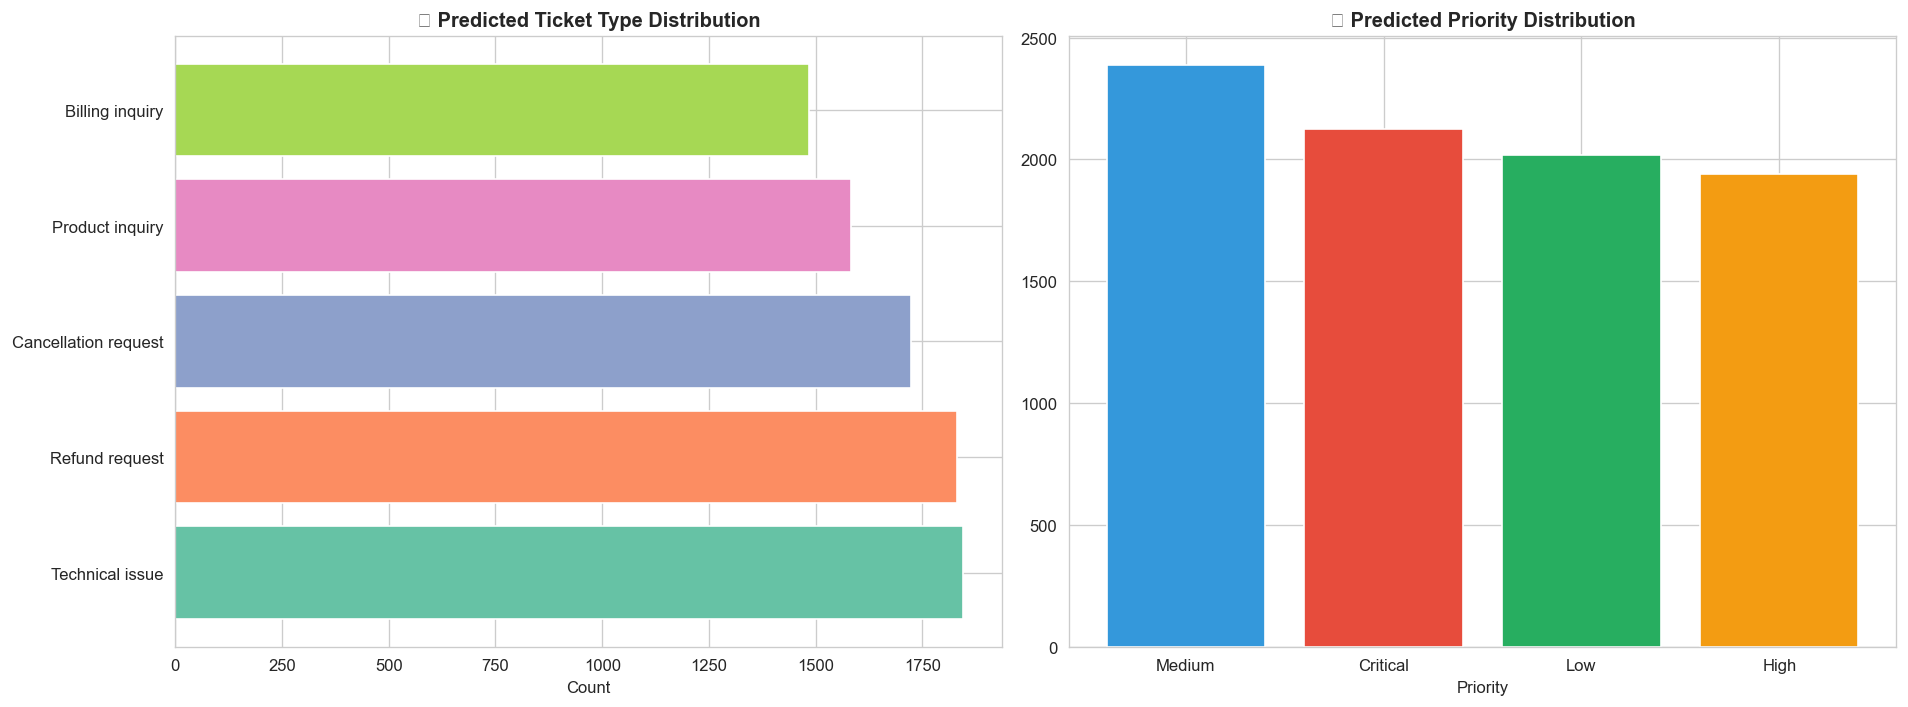

✅ Saved: output/07_predicted_distributions.png


In [17]:
# Analytics: predicted type and priority distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pred_type = df_full['predicted_type'].value_counts()
axes[0].barh(pred_type.index, pred_type.values,
             color=sns.color_palette('Set2', len(pred_type)))
axes[0].set_title('📂 Predicted Ticket Type Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')

pred_pri = df_full['predicted_priority'].value_counts()
colors_p = {'Critical':'#e74c3c','High':'#f39c12','Medium':'#3498db','Low':'#27ae60'}
bar_colors = [colors_p.get(p, 'gray') for p in pred_pri.index]
axes[1].bar(pred_pri.index, pred_pri.values, color=bar_colors)
axes[1].set_title('⚡ Predicted Priority Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Priority')

plt.tight_layout()
plt.savefig('output/07_predicted_distributions.png', bbox_inches='tight')
plt.show()
print('✅ Saved: output/07_predicted_distributions.png')

## 7. Test with New Tickets

In [18]:
def classify_ticket(subject, description):
    """Classify a new support ticket."""
    text = clean_text(subject) + ' ' + clean_text(description)
    pred_type     = le_type.inverse_transform(best_cat_pipe.predict([text]))[0]
    pred_priority = le_priority.inverse_transform(pri_pipe.predict([text]))[0]
    print(f'Subject    : {subject}')
    print(f'Predicted Type    : {pred_type}')
    print(f'Predicted Priority: {pred_priority}')
    print('-' * 50)

# Test examples
classify_ticket('Cannot login', 'I forgot my password and the reset email is not arriving. I need urgent access.')
classify_ticket('Wrong item delivered', 'I ordered a laptop but received a keyboard. Please resolve this soon.')
classify_ticket('Feature request', 'It would be nice to have dark mode support in the app.')
classify_ticket('App crashing', 'The application crashes every time I open the dashboard. Very frustrating.')

Subject    : Cannot login
Predicted Type    : Technical issue
Predicted Priority: High
--------------------------------------------------
Subject    : Wrong item delivered
Predicted Type    : Technical issue
Predicted Priority: Medium
--------------------------------------------------
Subject    : Feature request
Predicted Type    : Cancellation request
Predicted Priority: Critical
--------------------------------------------------
Subject    : App crashing
Predicted Type    : Billing inquiry
Predicted Priority: High
--------------------------------------------------


## 8. Summary

In [19]:
print('=' * 60)
print('   SUPPORT TICKET CLASSIFICATION – SUMMARY')
print('=' * 60)
print(f'\n📦 Dataset: customer_support_tickets.csv')
print(f'   Total tickets: {len(df)}')
print(f'   Ticket Types: {df["Ticket Type"].nunique()}')
print(f'   Priority Levels: {df["Ticket Priority"].nunique()}')
print('\n📊 Category Classification Results:')
for name, res in cat_results.items():
    print(f'   {name:25s} → Acc: {res["Accuracy"]:.4f} | F1: {res["F1 (weighted)"]:.4f}')
print(f'\n🏆 Best Ticket Type Classifier: {best_cat_name}')
print(f'\n⚡ Priority Classifier: Logistic Regression')
print(f'   Accuracy: {accuracy_score(yp_test, pri_preds):.4f}')
print(f'   F1 Score: {f1_score(yp_test, pri_preds, average="weighted"):.4f}')
print('\n✅ Output files saved to /output/')
print('=' * 60)

   SUPPORT TICKET CLASSIFICATION – SUMMARY

📦 Dataset: customer_support_tickets.csv
   Total tickets: 8469
   Ticket Types: 5
   Priority Levels: 4

📊 Category Classification Results:
   Naive Bayes               → Acc: 0.2054 | F1: 0.2039
   Logistic Regression       → Acc: 0.2102 | F1: 0.2100
   Random Forest             → Acc: 0.1942 | F1: 0.1937

🏆 Best Ticket Type Classifier: Logistic Regression

⚡ Priority Classifier: Logistic Regression
   Accuracy: 0.2491
   F1 Score: 0.2491

✅ Output files saved to /output/
